In [10]:
import pandas as pd
import numpy as np


In [11]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [12]:
train.shape, test.shape

((1460, 81), (1459, 80))

In [13]:
print(set(train.columns)-set(test.columns))

{'SalePrice'}


In [24]:
train.head(),train.describe()

(   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
 0   1          60       RL         65.0     8450   Pave   NaN      Reg   
 1   2          20       RL         80.0     9600   Pave   NaN      Reg   
 2   3          60       RL         68.0    11250   Pave   NaN      IR1   
 3   4          70       RL         60.0     9550   Pave   NaN      IR1   
 4   5          60       RL         84.0    14260   Pave   NaN      IR1   
 
   LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
 0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
 1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
 2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
 3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
 4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   
 
   YrSold  SaleType  SaleCondition  SalePrice  
 0   2

In [26]:
 # train.columns.value_counts()

In [27]:
import matplotlib.pyplot as plt

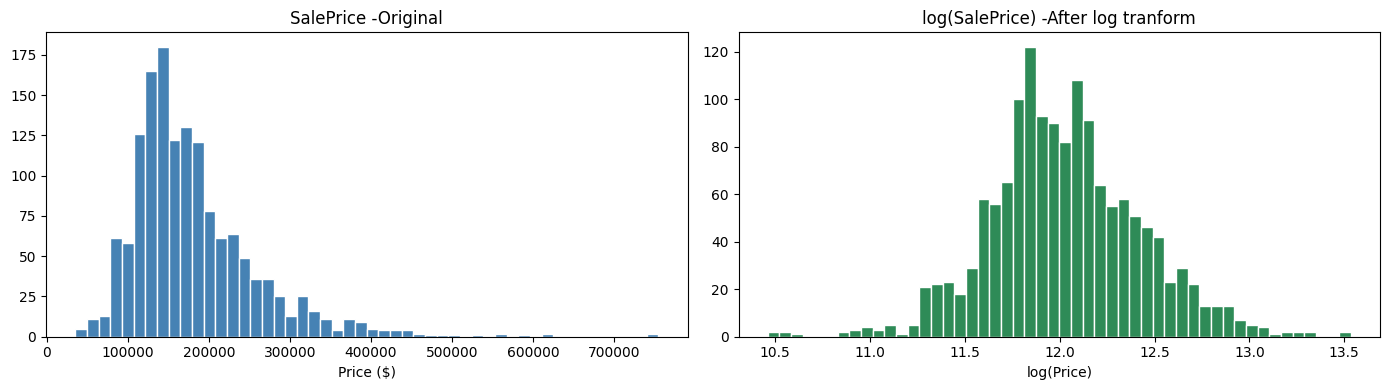

Skewness (Original) : 1.88
Skewness (Transform): 0.12


In [33]:
fig,axes = plt.subplots(1,2,figsize=(14,4))
axes[0].hist(train['SalePrice'],bins = 50,color = 'steelblue',edgecolor='white')
axes[0].set_title('SalePrice -Original')
axes[0].set_xlabel('Price ($)')

axes[1].hist(np.log1p(train['SalePrice']),bins=50,color='seagreen',edgecolor='white')
axes[1].set_title('log(SalePrice) -After log tranform')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

print("Skewness (Original) :", round(train['SalePrice'].skew(),2))
print("Skewness (Transform):", round(np.log1p(train['SalePrice']).skew(),2))



In [ ]:

# Missing Things in Data


In [34]:
missing = train.isnull().sum()
missing = missing[missing>0].sort_values(ascending=True)


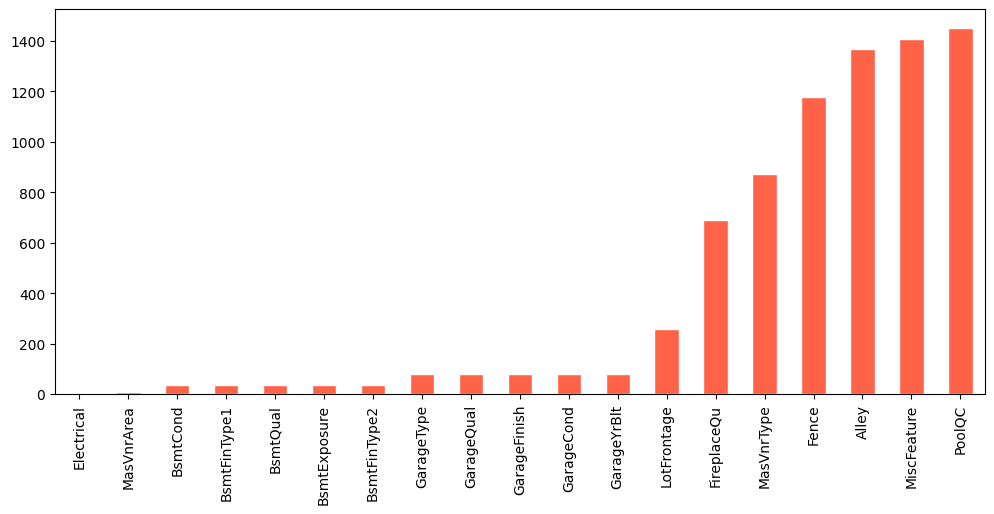

In [36]:
plt.figure(figsize=(12,5))
missing.plot(kind='bar',color='tomato',edgecolor ='white')
plt.show()

In [43]:
numeric_cols = train.select_dtypes(include='number')
corr = numeric_cols.corr()['SalePrice'].sort_values(ascending=True)

print("Top 15 with sales price\n\n",corr.head(15))
print("\n\nLast 5 \n\n",corr.tail(5))

Top 15 with sales price

 KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
Name: SalePrice, dtype: float64


Last 5 

 GarageArea     0.623431
GarageCars     0.640409
GrLivArea      0.708624
OverallQual    0.790982
SalePrice      1.000000
Name: SalePrice, dtype: float64


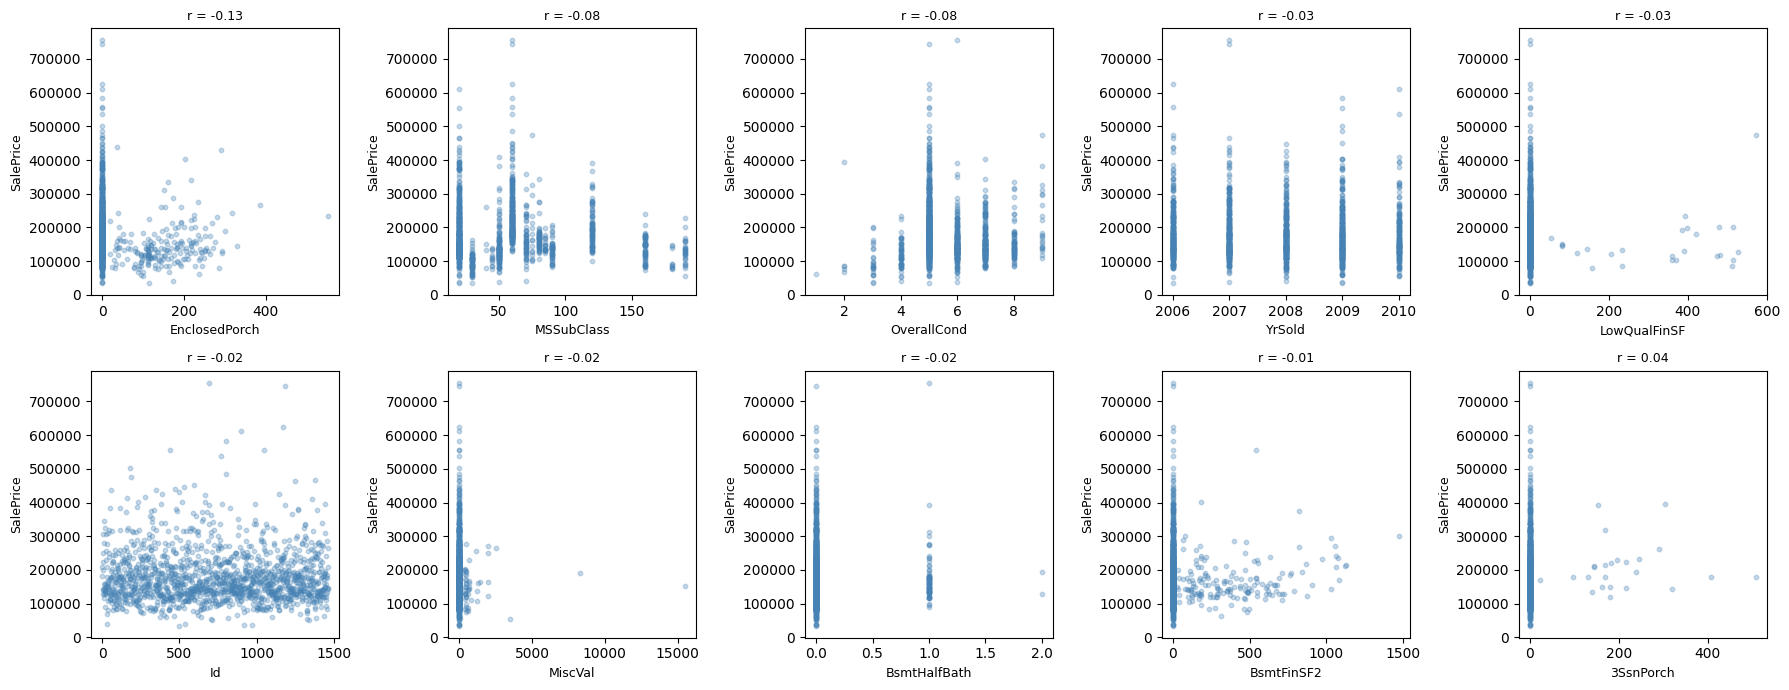

In [51]:
top_features = corr[1:11].index.tolist()

fig,axes =  plt.subplots(2,5,figsize= (18,7))
axes = axes.flatten()

for i,col in enumerate(top_features):
    axes[i].scatter(train[col],train['SalePrice'],alpha= 0.3,color = 'steelblue',s = 10)
    axes[i].set_xlabel(col,fontsize  =9)
    axes[i].set_ylabel('SalePrice',fontsize =9)
    axes[i].set_title(f'r = {corr[col]:.2f}',fontsize = 9)
plt.tight_layout()
plt.show()

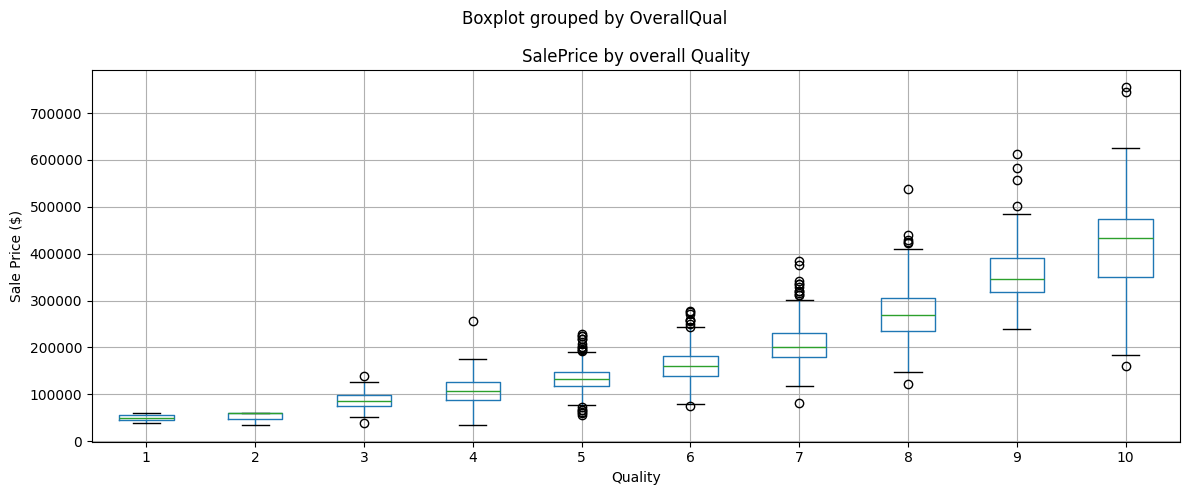

In [55]:
plt.Figure(figsize=(12,5))
train.boxplot(column='SalePrice',by='OverallQual',figsize=(12,5))
plt.title('SalePrice by overall Quality')
plt.xlabel('Quality')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

In [57]:
train_id = train['Id']
test_id = test['Id']
y = np.log1p(train['SalePrice'])

train_df = train.drop(['Id','SalePrice'],axis = 1)
test_df = test.drop(['Id'],axis = 1)
all_data = pd.concat([train_df,test_df],axis =0 ,ignore_index  = True)

print(f"Combined Shape:{all_data.shape}")
print(f"train Rows:{len(train_df)}| test rows: {len(test_df)}")


Combined Shape:(2919, 79)
train Rows:1460| test rows: 1459


In [58]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [59]:
test.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [64]:
# Finding Null Values

In [62]:
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

In [63]:
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')


In [65]:
zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

In [66]:
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

In [68]:

all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))


In [69]:
for col in all_data.columns:
    if all_data[col].isnull().sum() > 0:
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

In [70]:
print({all_data.isnull().sum().sum()})

{np.int64(0)}
